# Analisis Descriptivo Univariado — Dataset Competentes

**Fuente**: `data/ia_comp.xlsx` (503 encuestas a personas en busqueda de empleo / interesadas
en mejorar su empleabilidad)

**Objetivo (Pipeline Step 3)**: replicar la estructura del analisis univariado del dataset
PyMEs (Step 2) sobre el dataset de Competentes — tablas de frecuencia, graficos de barras y
analisis de valores faltantes — incluyendo el tratamiento especifico del bloque de respuesta
multiple `p_02a`–`p_02e` (apoyo requerido en la busqueda de empleo), para permitir comparaciones
directas entre ambos datasets en etapas posteriores (Steps 6 y 11).

## Tabla de contenidos

1. [Notas de preparacion de datos](#1.-Notas-de-preparacion-de-datos)
2. [Resumen del dataset](#2.-Resumen-del-dataset)
3. [Perfil demografico](#3.-Perfil-demografico)
    - [3.1 Sexo](#3.1-Sexo)
    - [3.2 Rango etario (edad)](#3.2-Rango-etario-(edad))
    - [3.3 Nivel educacional (niveduc)](#3.3-Nivel-educacional-(niveduc))
    - [3.4 Ocupacion](#3.4-Ocupacion)
    - [3.5 Grupo socioeconomico (nse)](#3.5-Grupo-socioeconomico-(nse))
4. [Variables de respuesta de busqueda de empleo](#4.-Variables-de-respuesta-de-busqueda-de-empleo)
    - [4.1 p01 — Principal barrera para aprender herramientas digitales](#4.1-p01-—-Principal-barrera-para-aprender-herramientas-digitales)
    - [4.2 p_02a–p_02e — Apoyo requerido en la busqueda de empleo (multi-respuesta)](#4.2-p_02a–p_02e-—-Apoyo-requerido-en-la-busqueda-de-empleo-(multi-respuesta))
    - [4.3 p03 — Interes en formacion de habilidades via movil](#4.3-p03-—-Interes-en-formacion-de-habilidades-via-movil)
5. [Analisis de valores faltantes](#5.-Analisis-de-valores-faltantes)
6. [Resumen de hallazgos clave](#6.-Resumen-de-hallazgos-clave)


## 1. Notas de preparacion de datos

Este notebook reutiliza los mismos helpers (`analysis_helpers.py`) validados y corregidos
durante el analisis de PyMEs (Step 2). A diferencia de `PYMES_CODES`, la lista `COMP_CODES` ya
declaraba los 15 codigos correctos desde el Step 1 (5 demograficos + `p01`/`p01_otro` +
`p_02a`–`p_02e` + `p02_otro` + `p03`), por lo que **no fue necesario corregir el mapeo de
columnas** para este dataset — el rename map generado por `build_rename_map()` calza 1:1 con el
diccionario documentado en `CLAUDE.md`.

Se heredan automaticamente (por ser correcciones a nivel de helper, no de dataset) los tres
ajustes ya aplicados en el Step 2:

1. `lowercase_df()` normaliza columnas de texto en pandas 3.0 (dtype `str`, no solo `object`).
2. `normalize_text()` colapsa espacios alrededor de guiones (`"[31 - 40]"` → `"[31-40]"`) para
   que `edad` ordene correctamente.
3. `CATEGORY_ORDERS["niveduc"]` incluye los extremos `basica incompleta/completa` y `postgrado`.

Dos observaciones especificas de este dataset:

- **`ocupacion` conserva las mismas 3 categorias fuera del orden jerarquico documentado**
  (`alto(a) ejecutivo(a)`, `ejecutivo(a) medio(a) / profesional independiente`,
  `trabajos menores e informales`), que en conjunto representan **29.2% de la muestra** — ver
  Seccion 3.4.
- **`edad` no registra ningun respondente en el tramo `[61+]`** de los 5 niveles canonicos
  definidos en `CATEGORY_ORDERS`; la categoria queda automaticamente excluida del eje del
  grafico de barras al no estar observada (`apply_categoricals` solo incluye niveles presentes
  en los datos) — ver Seccion 3.2.


In [1]:
from analysis_helpers import *
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

dfcomp = load_survey(COMP_PATH, COMP_CODES, dataset="comp")
set_theme("light")


Rename map (raw header -> code):
  id         <- 'ID'
  sexo       <- 'SEXO'
  edad       <- 'RANGO ETARIO'
  niveduc    <- '¿NIVEL EDUCACIONAL?'
  ocupacion  <- '¿TIPO DE TRABAJO?'
  nse        <- 'GRUPO NSE'
  p01        <- '¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total)'
  p01_otro   <- '¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique))'
  p_02a      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Armar o mejorar mi CV)'
  p_02b      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prepararme para una entrevista)'
  p_02c      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Buscar ofertas de trabajo)'
  p_02d      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda

/Users/tomas/github/icd_ia/analysis_helpers.py:354: UserWarning: Column 'ocupacion' has 3 value(s) outside the canonical ordering: ['alto(a) ejecutivo(a)', 'ejecutivo(a) medio(a) / profesional independiente', 'trabajos menores e informales'] -- appended as trailing categories.
  df = apply_categoricals(df, strict=strict, verbose=verbose)


<module 'matplotlib.pyplot' from '/Users/tomas/.pyenv/versions/3.14.6/lib/python3.14/site-packages/matplotlib/pyplot.py'>

## 2. Resumen del dataset

Vista general de columnas, tipos de dato y completitud antes de entrar al detalle
variable por variable.

In [2]:
labeled_info(dfcomp)

,code,label,dtype,n_valid,n_missing,pct_missing,n_unique
0,id,ID,int64,503,0,0.0,503
1,sexo,SEXO,category,503,0,0.0,2
2,edad,RANGO ETARIO,category,503,0,0.0,4
3,niveduc,¿NIVEL EDUCACIONAL?,category,503,0,0.0,8
4,ocupacion,¿TIPO DE TRABAJO?,category,503,0,0.0,10
5,nse,GRUPO NSE,category,502,1,0.2,4
6,p01,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total),str,503,0,0.0,6
7,p01_otro,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),float64,0,503,100.0,0
8,p_02a,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Arma...",str,189,314,62.4,1
9,p_02b,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prep...",str,152,351,69.8,1


In [3]:
labeled_head(dfcomp, 5)

,id\nID,sexo\nSEXO,edad\nRANGO ETARIO,niveduc\n¿NIVEL EDUCACIONAL?,ocupacion\n¿TIPO DE TRABAJO?,nse\nGRUPO NSE,p01\n¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total),p01_otro\n¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),"p_02a\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Armar o mejorar mi CV)","p_02b\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prepararme para una entrevista)","p_02c\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Buscar ofertas de trabajo)","p_02d\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Contactar empresas)","p_02e\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ninguna / no necesito ayuda)","p02_otro\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Otro (especifique))",p03\n¿Te parecería atractivo aprender nuevas habilidades para mejorar tu empleabilidad en lecciones cortas a través de tu celular?
0,1,masculino,[41-50],tecnica superior completa,empleado(a) administrativo(a) / tecnico,c2,falta de tiempo,NaN,NaN,NaN,buscar ofertas de trabajo,NaN,NaN,NaN,sí
1,2,femenino,[41-50],media completa,oficio calificado,c3,falta de tiempo,NaN,NaN,prepararme para una entrevista,NaN,NaN,NaN,NaN,sí
2,3,femenino,[31-40],universitaria incompleta,cesante,c3,nada me frena,NaN,armar o mejorar mi cv,NaN,NaN,NaN,NaN,NaN,sí
3,4,femenino,[41-50],media completa,dueño(a) de casa,d+e,falta de confianza / me da inseguridad,NaN,NaN,prepararme para una entrevista,NaN,NaN,NaN,NaN,sí
4,5,masculino,[31-40],tecnica superior incompleta,oficio menor,c3,falta de tiempo,NaN,NaN,prepararme para una entrevista,NaN,NaN,NaN,NaN,sí


### Interpretacion — Resumen del dataset (Hallazgo 1)

El dataset tiene **503 respuestas y 15 columnas**: 5 variables demograficas (`sexo`, `edad`,
`niveduc`, `ocupacion`, `nse`), 2 preguntas cerradas (`p01`, `p03`), un bloque de 5 columnas de
respuesta multiple (`p_02a`–`p_02e`, apoyo requerido en la busqueda de empleo) y 2 campos de
texto libre "otro" (`p01_otro`, `p02_otro`). Las 6 variables cerradas de uso directo
(`sexo`, `edad`, `niveduc`, `ocupacion`, `p01`, `p03`) tienen **0% de valores faltantes**; `nse`
tiene **1 caso sin dato (0.2%)**, el unico faltante entre las variables demograficas — a
diferencia de PyMEs, donde `nse` estaba 100% completa. Los 2 campos "otro" estan **100%
vacios**, igual que en PyMEs. Las 5 columnas `p_02a`–`p_02e` muestran un patron de faltantes
muy distinto (60%–88.7%) que **no representa no-respuesta**, sino la codificacion habitual de
preguntas de opcion multiple: `NaN` significa "opcion no seleccionada" (ver Seccion 4.2 y 5).

## 3. Perfil demografico

### 3.1 Sexo

In [4]:
tbl_sexo = labeled_value_counts_detailed(dfcomp, "sexo")
tbl_sexo

sexo - SEXO   (n = 503)
------------------------------------------------------------------------
  femenino                             255   50.7%  ##############################
  masculino                            248   49.3%  #############################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,femenino,255,50.7,50.7,50.7
1,masculino,248,49.3,49.3,100.0


findfont: Failed to find font weight semibold, now using 700.


'/Users/tomas/github/icd_ia/figures/comp/comp_sexo_bar.png'

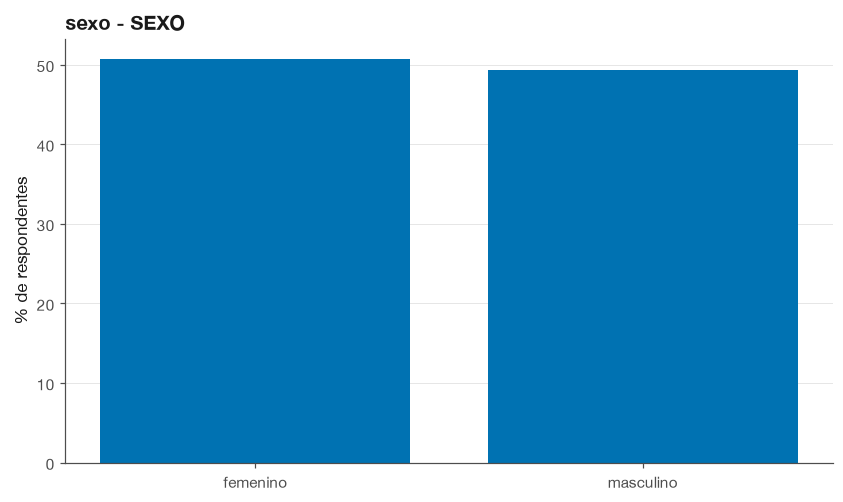

In [5]:
ax = bar_freq(dfcomp, "sexo", horizontal=False)
save_fig(ax, "comp_sexo_bar.png", subdir="comp")

**Interpretacion (Hallazgo 2):** la muestra esta **practicamente equilibrada por
genero** (50.7% femenino vs. 49.3% masculino, 255 vs. 248 respondentes), en linea con el
equilibrio observado en PyMEs (52.2%/47.8%), por lo que el sexo no introduce un sesgo relevante
para las comparaciones entre datasets en etapas posteriores.

### 3.2 Rango etario (edad)

In [6]:
tbl_edad = labeled_value_counts_detailed(dfcomp, "edad")
tbl_edad

edad - RANGO ETARIO   (n = 503)
------------------------------------------------------------------------
  [18-30]                               65   12.9%  ############
  [31-40]                              142   28.2%  ###########################
  [41-50]                              157   31.2%  ##############################
  [51-60]                              139   27.6%  ###########################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,[18-30],65,12.9,12.9,12.9
1,[31-40],142,28.2,28.2,41.1
2,[41-50],157,31.2,31.2,72.3
3,[51-60],139,27.6,27.6,99.9


'/Users/tomas/github/icd_ia/figures/comp/comp_edad_bar.png'

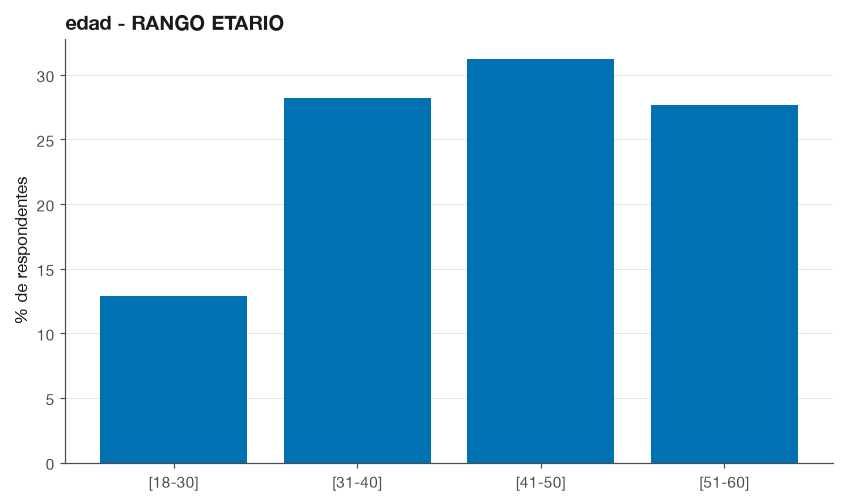

In [7]:
ax = bar_freq(dfcomp, "edad", horizontal=False)
save_fig(ax, "comp_edad_bar.png", subdir="comp")

**Interpretacion (Hallazgo 3):** la edad se concentra en los **tramos intermedios**:
`[41-50]` (31.2%) y `[31-40]` (28.2%) son los mas numerosos, seguidos de cerca por `[51-60]`
(27.6%); el tramo joven `[18-30]` es minoritario (12.9%). El hallazgo mas notable es
**estructural**: no hay ningun respondente en `[61+]`, el tramo de mayor edad del orden
canonico (que en PyMEs concentraba 19.8% de la muestra). Esto es consistente con el foco del
instrumento en personas activamente buscando empleo o mejorando su empleabilidad, un perfil
menos frecuente en la poblacion de 61 años o mas.

### 3.3 Nivel educacional (niveduc)

In [8]:
tbl_niveduc = labeled_value_counts_detailed(dfcomp, "niveduc")
tbl_niveduc

niveduc - ¿NIVEL EDUCACIONAL?   (n = 503)
------------------------------------------------------------------------
  basica completa                        1    0.2%  
  media incompleta                       2    0.4%  
  media completa                       114   22.7%  #######################
  tecnica superior incompleta           51   10.1%  ##########
  tecnica superior completa            105   20.9%  #####################
  universitaria incompleta              52   10.3%  ##########
  universitaria completa               150   29.8%  ##############################
  postgrado                             28    5.6%  ######
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,basica completa,1,0.2,0.2,0.2
1,media incompleta,2,0.4,0.4,0.6
2,media completa,114,22.7,22.7,23.3
3,tecnica superior incompleta,51,10.1,10.1,33.4
4,tecnica superior completa,105,20.9,20.9,54.3
5,universitaria incompleta,52,10.3,10.3,64.6
6,universitaria completa,150,29.8,29.8,94.4
7,postgrado,28,5.6,5.6,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_niveduc_bar.png'

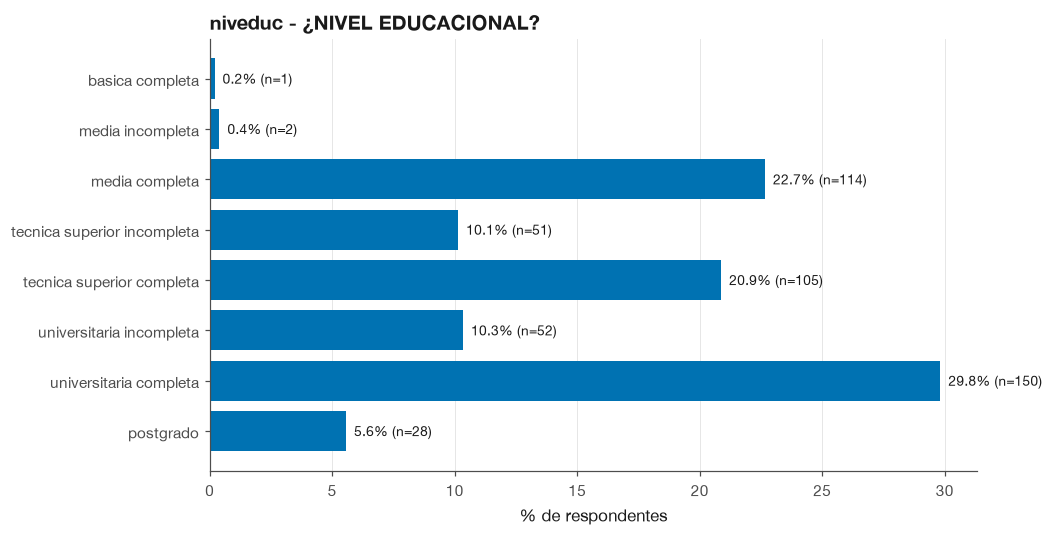

In [9]:
ax = bar_freq(dfcomp, "niveduc", horizontal=True)
save_fig(ax, "comp_niveduc_bar.png", subdir="comp")

**Interpretacion (Hallazgo 4):** el nivel educacional muestra una **mayoria clara de
formacion post-secundaria**: sumando tecnica superior (completa+incompleta, 31.0%) y
universitaria (completa+incompleta, 40.1%), el **71.1%** de la muestra tiene formacion
post-secundaria, y si se agrega postgrado (5.6%) el total con formacion terciaria o superior
sube a **76.7%** — un nivel educativo levemente mas alto que en PyMEs (70.7%). La educacion
basica es marginal (0.6% combinado, apenas 3 casos) y "media completa" es el tercer nivel mas
frecuente (22.7%), consistente con un perfil orientado a empleabilidad y busqueda activa de
mejores oportunidades laborales.

### 3.4 Ocupacion

In [10]:
tbl_ocupacion = labeled_value_counts_detailed(dfcomp, "ocupacion")
tbl_ocupacion

ocupacion - ¿TIPO DE TRABAJO?   (n = 503)
------------------------------------------------------------------------
  cesante                               51   10.1%  ##########
  estudiante                            19    3.8%  ####
  dueño(a) de casa                      29    5.8%  ######
  jubilado(a)                            6    1.2%  #
  oficio menor                          29    5.8%  ######
  oficio calificado                     67   13.3%  #############
  empleado(a) administrativo(a) /      155   30.8%  ##############################
  alto(a) ejecutivo(a)                  12    2.4%  ##
  ejecutivo(a) medio(a) / profesio      86   17.1%  #################
  trabajos menores e informales         49    9.7%  #########
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,cesante,51,10.1,10.1,10.1
1,estudiante,19,3.8,3.8,13.9
2,dueño(a) de casa,29,5.8,5.8,19.7
3,jubilado(a),6,1.2,1.2,20.9
4,oficio menor,29,5.8,5.8,26.7
5,oficio calificado,67,13.3,13.3,40.0
6,empleado(a) administrativo(a) / tecnico,155,30.8,30.8,70.8
7,alto(a) ejecutivo(a),12,2.4,2.4,73.2
8,ejecutivo(a) medio(a) / profesional independiente,86,17.1,17.1,90.3
9,trabajos menores e informales,49,9.7,9.7,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_ocupacion_bar.png'

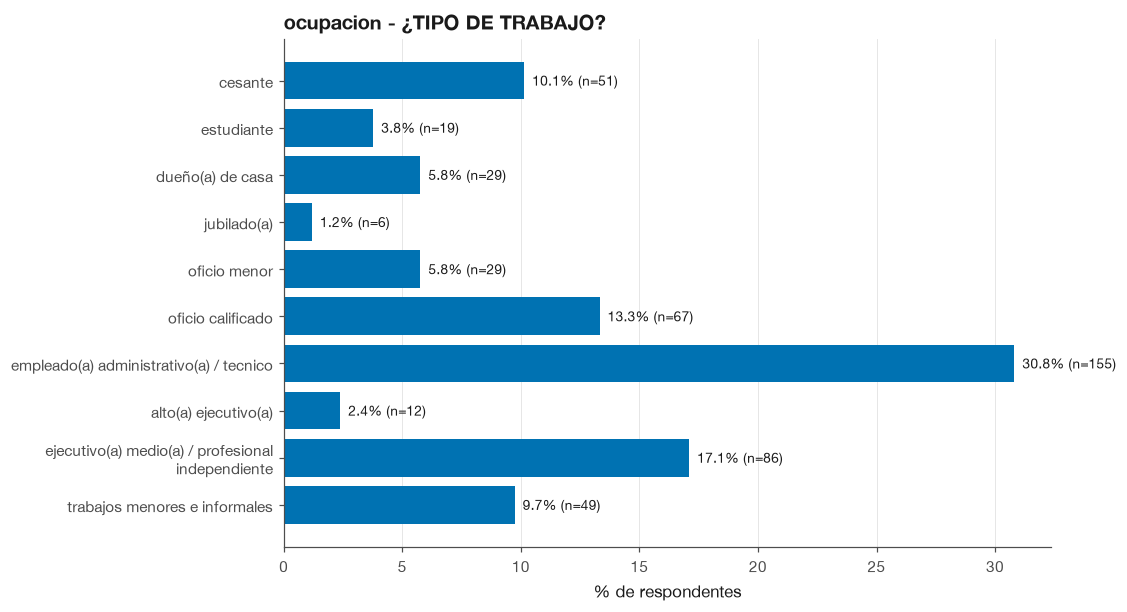

In [11]:
ax = bar_freq(dfcomp, "ocupacion", horizontal=True)
save_fig(ax, "comp_ocupacion_bar.png", subdir="comp")

**Interpretacion (Hallazgo 5):** la categoria mas frecuente es "empleado(a)
administrativo(a) / tecnico" (30.8%), seguida de "ejecutivo(a) medio(a) / profesional
independiente" (17.1%) y "oficio calificado" (13.3%). Un hallazgo relevante para el diseño de
intervenciones es que **solo 10.1% declara estar cesante** (desempleado/a): la mayoria de la
muestra de "competentes" ya esta empleada y busca **mejorar su empleabilidad o cambiar de
trabajo**, no encontrar un primer empleo. **Nota de calidad de datos (igual que en PyMEs):** las
3 categorias fuera del orden jerarquico documentado ("alto(a) ejecutivo(a)" 2.4%,
"ejecutivo(a) medio(a) / profesional independiente" 17.1%, "trabajos menores e informales" 9.7%)
suman **29.2%** de la muestra y requieren definicion de negocio antes de tratarse como escala
ordinal (ver Seccion 1).

### 3.5 Grupo socioeconomico (nse)

In [12]:
tbl_nse = labeled_value_counts_detailed(dfcomp, "nse")
tbl_nse

nse - GRUPO NSE   (n = 503)
------------------------------------------------------------------------
  d+e                                   49    9.7%  #######
  c3                                   144   28.6%  ####################
  c2                                   218   43.3%  ##############################
  abc1                                  91   18.1%  #############
  nan                                    1    0.2%  
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,d+e,49,9.7,9.8,9.8
1,c3,144,28.6,28.7,38.5
2,c2,218,43.3,43.4,81.9
3,abc1,91,18.1,18.1,100.0
4,NaN,1,0.2,NaN,NaN


'/Users/tomas/github/icd_ia/figures/comp/comp_nse_bar.png'

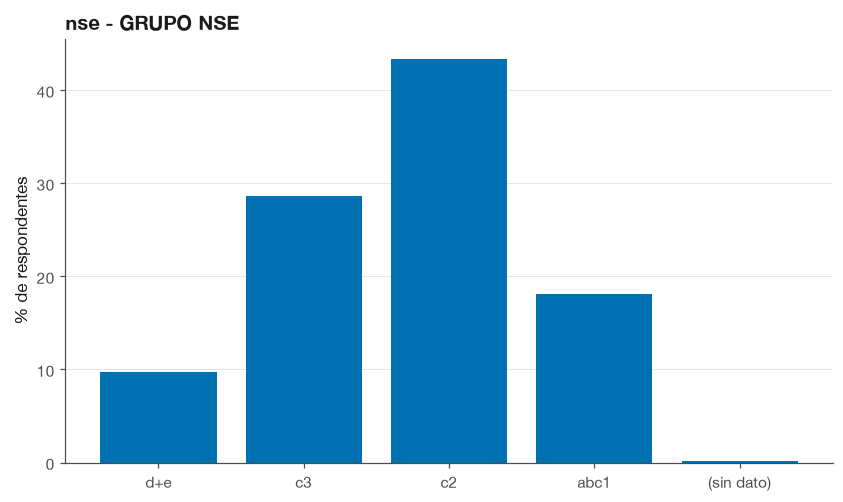

In [13]:
ax = bar_freq(dfcomp, "nse", horizontal=False)
save_fig(ax, "comp_nse_bar.png", subdir="comp")

**Interpretacion (Hallazgo 6):** el grupo socioeconomico esta **fuertemente
concentrado en el segmento medio** (c2 43.4% + c3 28.7% = 72.1% de los casos validos), una
concentracion aun mayor que en PyMEs (68.8%). Los extremos son minoritarios: d+e (9.8%) y abc1
(18.1%). A diferencia de PyMEs (0 faltantes), `nse` tiene **1 respondente sin dato** en este
dataset (0.2%), el unico valor faltante entre las variables demograficas.

## 4. Variables de respuesta de busqueda de empleo

### 4.1 p01 — Principal barrera para aprender herramientas digitales

In [14]:
tbl_p01 = labeled_value_counts_detailed(dfcomp, "p01")
tbl_p01

p01 - ¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total)   (n = 503)
------------------------------------------------------------------------
  falta de tiempo                      179   35.6%  ##############################
  nada me frena                        163   32.4%  ###########################
  falta de confianza / me da inseg      50    9.9%  ########
  falta de conocimientos o habilid      88   17.5%  ###############
  falta de equipo o conexión a int      16    3.2%  ###
  no le veo utilidad para mi traba       7    1.4%  #
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,falta de tiempo,179,35.6,35.6,35.6
1,nada me frena,163,32.4,32.4,68.0
2,falta de confianza / me da inseguridad,50,9.9,9.9,77.9
3,falta de conocimientos o habilidades,88,17.5,17.5,95.4
4,falta de equipo o conexión a internet,16,3.2,3.2,98.6
5,no le veo utilidad para mi trabajo,7,1.4,1.4,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_p01_bar.png'

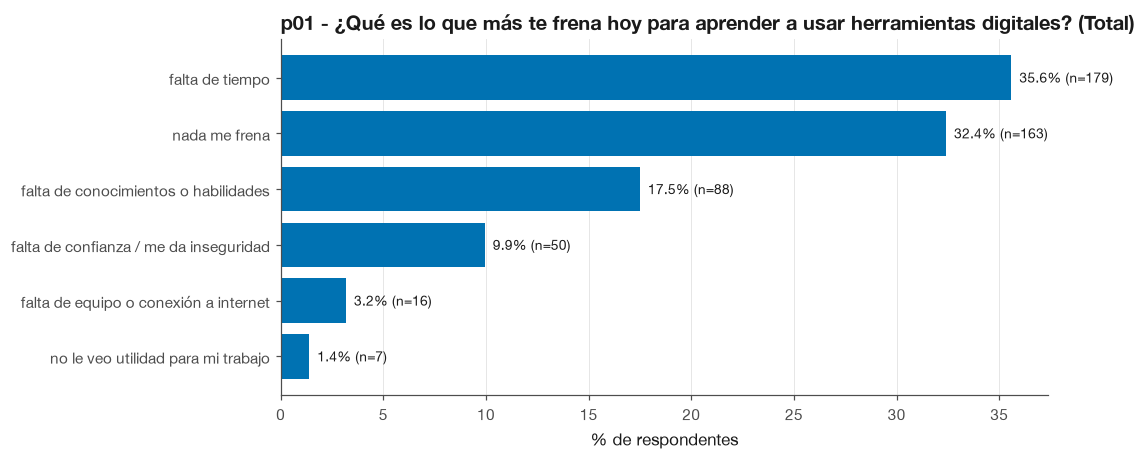

In [15]:
ax = bar_freq(dfcomp, "p01", horizontal=True)
save_fig(ax, "comp_p01_bar.png", subdir="comp")

**Interpretacion (Hallazgo 7):** la distribucion de barreras es **marcadamente
bimodal**: "falta de tiempo" (35.6%) y "nada me frena" (32.4%) concentran juntas el **68.0%**
de las respuestas, con una diferencia de solo 3.2 puntos porcentuales entre ambas. Le siguen
"falta de conocimientos o habilidades" (17.5%) y "falta de confianza / me da inseguridad"
(9.9%); las barreras estructurales —"falta de equipo o conexion a internet" (3.2%) y "no le veo
utilidad para mi trabajo" (1.4%)— son minoritarias. A diferencia de PyMEs, donde una sola
barrera ("falta de capital", 60.3%) domina claramente, aqui **casi un tercio de la muestra no
percibe ninguna barrera relevante**, lo que sugiere que la principal palanca de intervencion es
la gestion del tiempo disponible, mas que el acceso a equipamiento o la confianza.

### 4.2 p_02a–p_02e — Apoyo requerido en la busqueda de empleo (multi-respuesta)

Este bloque es de **respuesta multiple**: cada respondente pudo seleccionar cero, una o
varias opciones de apoyo. Por eso se analiza con `multiselect_summary()` en vez de
`freq_table()`/`bar_freq()` — cada columna es binaria (seleccionada / no seleccionada) y las
tasas de seleccion no suman 100%.

In [16]:
ms_p02 = multiselect_summary(dfcomp, COMP_MULTISELECT)
ms_p02

Respondents: 503 | selections per respondent: mean 1.43, max 4


,code,label,n_selected,pct_of_respondents
0,p_02a,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Arma...",189,37.6
1,p_02b,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prep...",152,30.2
2,p_02c,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Busc...",201,40.0
3,p_02d,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Cont...",120,23.9
4,p_02e,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ning...",57,11.3


'/Users/tomas/github/icd_ia/figures/comp/comp_p02_multiselect_bar.png'

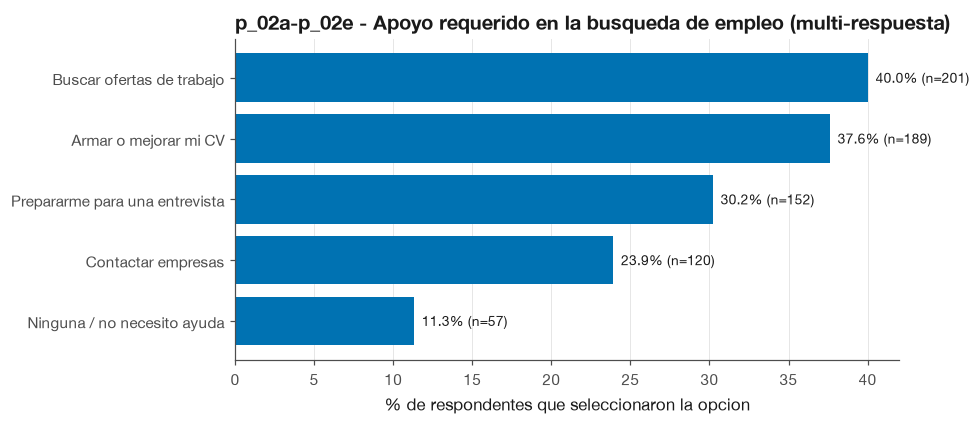

In [17]:
import matplotlib.pyplot as plt

item_labels = {
    "p_02a": "Armar o mejorar mi CV",
    "p_02b": "Prepararme para una entrevista",
    "p_02c": "Buscar ofertas de trabajo",
    "p_02d": "Contactar empresas",
    "p_02e": "Ninguna / no necesito ayuda",
}
order = ms_p02.sort_values("n_selected", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
pos = range(len(order))
ax.barh(pos, order["pct_of_respondents"], color=PALETTE[0])
ax.set_yticks(list(pos), [item_labels[c] for c in order["code"]])
for p, pct, n in zip(pos, order["pct_of_respondents"], order["n_selected"]):
    ax.text(pct, p, f"  {pct:.1f}% (n={n})", va="center", fontsize=9)
ax.set_xlabel("% de respondentes que seleccionaron la opcion")
ax.set_title("p_02a-p_02e - Apoyo requerido en la busqueda de empleo (multi-respuesta)",
             loc="left")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_fig(fig, "comp_p02_multiselect_bar.png", subdir="comp")


Respondentes: 503
  0 selecciones :    0  (0.0%)
  1 seleccion   :  378  (75.1%)
  2+ selecciones:  125  (24.9%)
  media = 1.43, maximo = 4


'/Users/tomas/github/icd_ia/figures/comp/comp_p02_selections_per_respondent_bar.png'

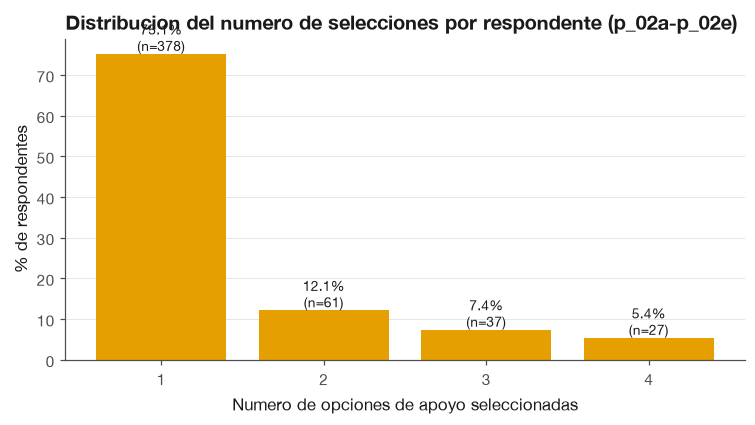

In [18]:
per_person = dfcomp[COMP_MULTISELECT].notna().sum(axis=1)
sel_counts = per_person.value_counts().sort_index()

print(f"Respondentes: {len(dfcomp)}")
print(f"  0 selecciones : {int((per_person == 0).sum()):>4}  "
      f"({100 * (per_person == 0).mean():.1f}%)")
print(f"  1 seleccion   : {int((per_person == 1).sum()):>4}  "
      f"({100 * (per_person == 1).mean():.1f}%)")
print(f"  2+ selecciones: {int((per_person >= 2).sum()):>4}  "
      f"({100 * (per_person >= 2).mean():.1f}%)")
print(f"  media = {per_person.mean():.2f}, maximo = {int(per_person.max())}")

fig, ax = plt.subplots(figsize=(7, 4))
vals = 100 * sel_counts / len(dfcomp)
ax.bar(sel_counts.index.astype(str), vals.values, color=PALETTE[1])
for x, (v, n) in enumerate(zip(vals.values, sel_counts.values)):
    ax.text(x, v, f"{v:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Numero de opciones de apoyo seleccionadas")
ax.set_ylabel("% de respondentes")
ax.set_title("Distribucion del numero de selecciones por respondente (p_02a-p_02e)",
             loc="left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "comp_p02_selections_per_respondent_bar.png", subdir="comp")


**Interpretacion (Hallazgo 8):** "buscar ofertas de trabajo" (40.0%) y "armar o
mejorar mi CV" (37.6%) son los apoyos **mas demandados**, seguidos de "prepararme para una
entrevista" (30.2%) y "contactar empresas" (23.9%). Solo **11.3%** selecciona "ninguna / no
necesito ayuda", confirmando que la gran mayoria de la muestra si valora algun tipo de apoyo
digital en su busqueda de empleo. En terminos de intensidad de la demanda: **ningun
respondente selecciono cero opciones** (todos marcaron al menos una, incluyendo quienes
eligieron explicitamente "ninguna"), el **75.1%** (378/503) seleccion una sola opcion y el
**24.9%** (125/503) selecciono dos o mas — con un maximo de 4 opciones simultaneas y un
promedio de 1.43 selecciones por respondente. Esto sugiere que, si bien la demanda de apoyo es
amplia, **la mayoria tiene una necesidad puntual y especifica** (CV o busqueda de ofertas) mas
que una necesidad integral de acompañamiento en todo el proceso.

### 4.3 p03 — Interes en formacion de habilidades via movil

In [19]:
tbl_p03 = labeled_value_counts_detailed(dfcomp, "p03")
tbl_p03

p03 - ¿Te parecería atractivo aprender nuevas habilidades para mejorar tu empleabilidad en lecciones cortas a través de tu celular?   (n = 503)
------------------------------------------------------------------------
  sí                                   454   90.3%  ##############################
  no                                    49    9.7%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,sí,454,90.3,90.3,90.3
1,no,49,9.7,9.7,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_p03_bar.png'

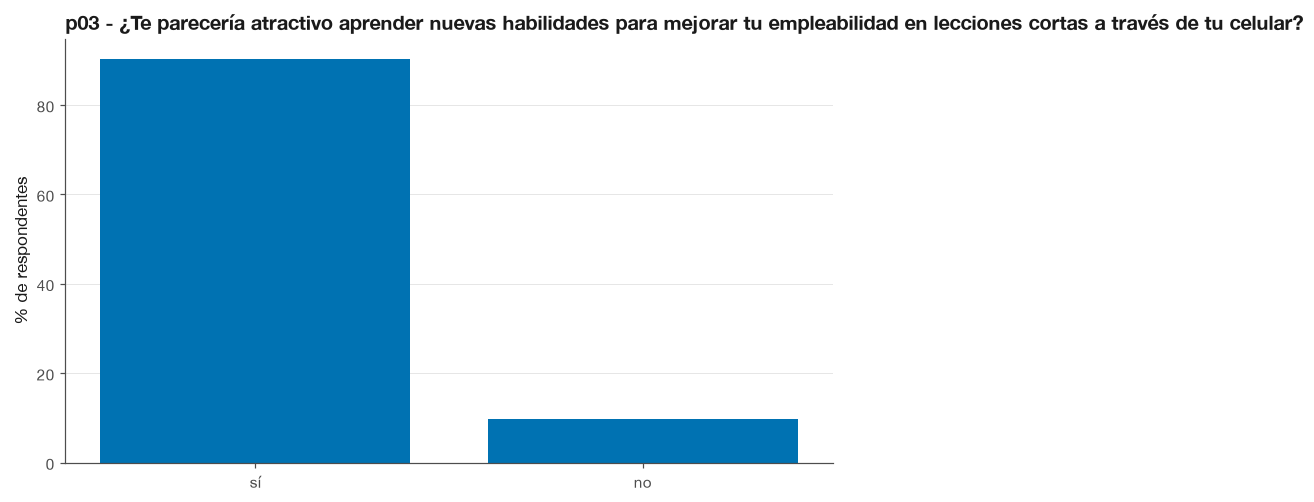

In [20]:
ax = bar_freq(dfcomp, "p03", horizontal=False)
save_fig(ax, "comp_p03_bar.png", subdir="comp")

**Interpretacion (Hallazgo 9):** el interes en formacion de habilidades en lecciones
cortas a traves del celular es **muy alto**: el **90.3%** (454 de 503) responde "si", frente a
solo 9.7% que responde "no". Esta señal es aun mas favorable que la disposicion a aprender
observada en PyMEs (94.3% dispuesto a dedicar tiempo semanal, aunque medida con una escala
distinta) y refuerza que el formato movil/microlearning es un canal prometedor para las
intervenciones de capacitacion digital dirigidas a este grupo (Step 10, Caso de uso 3).

## 5. Analisis de valores faltantes

In [21]:
missingness_report(dfcomp)

,code,label,n_missing,pct_missing
0,p01_otro,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),503,100.0
1,p02_otro,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Otro...",503,100.0
2,p_02e,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ning...",446,88.7
3,p_02d,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Cont...",383,76.1
4,p_02b,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prep...",351,69.8
5,p_02a,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Arma...",314,62.4
6,p_02c,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Busc...",302,60.0
7,nse,GRUPO NSE,1,0.2
8,id,ID,0,0.0
9,sexo,SEXO,0,0.0


'/Users/tomas/github/icd_ia/figures/comp/comp_missingness_heatmap.png'

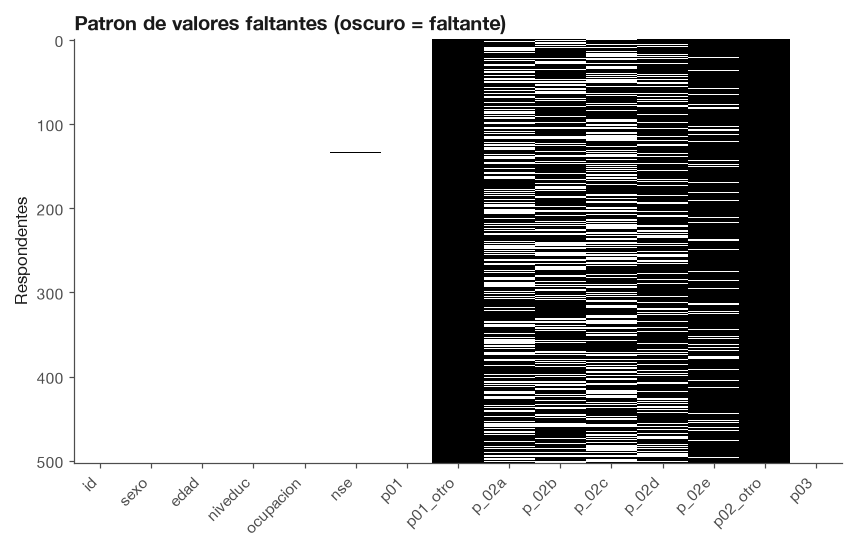

In [22]:
ax = missingness_heatmap(dfcomp)
save_fig(ax, "comp_missingness_heatmap.png", subdir="comp")

**Interpretacion (Hallazgo 10):** el patron de valores faltantes de Competentes es
**mas heterogeneo que el de PyMEs** y combina dos mecanismos distintos:

1. **Faltante estructural por diseño de "otro" (100%)** — `p01_otro` y `p02_otro` estan
   completamente vacias porque nadie usó la opcion de texto libre, igual que en PyMEs.
2. **Faltante estructural por diseño multi-respuesta (60.0%–88.7%)** — `p_02a`–`p_02e` no son
   no-respuesta: un `NaN` significa que esa opcion especifica **no fue una de las
   seleccionadas** por el respondente (que sí respondio el bloque, solo que con otras opciones).
   Esto se refleja en el mapa de calor como bandas parcialmente oscuras y de intensidad variable
   en las 5 columnas del bloque `p_02`, muy distinto del patron todo-o-nada de PyMEs.
3. **Faltante genuino y minimo (0.2%)** — solo 1 caso sin dato en `nse`, el unico valor
   verdaderamente ausente entre `id`, las 5 variables demograficas y las preguntas cerradas
   `p01`/`p03`.

En sintesis, la "falta de dato" en este dataset debe interpretarse columna por columna: en
`p_02a`–`p_02e` es informativa (indica que opcion no fue elegida), mientras que en `nse` es
efectivamente no-respuesta.

## 6. Resumen de hallazgos clave

1. **Muestra:** 503 personas en busqueda de empleo / interesadas en mejorar su empleabilidad,
   con cobertura completa en demografia y preguntas cerradas salvo 1 caso sin dato en `nse`;
   los 2 campos de texto libre "otro" estan vacios y el bloque `p_02a`–`p_02e` tiene
   faltantes estructurales propios de una pregunta de opcion multiple.
2. **Sexo:** practicamente equilibrado (50.7% femenino / 49.3% masculino).
3. **Edad:** concentrada en tramos `[31-40]`–`[51-60]` (87.0% combinado); **sin ningun
   respondente en `[61+]`**, a diferencia de PyMEs (19.8%).
4. **Educacion:** mayoritariamente post-secundaria (76.7% con formacion tecnica, universitaria
   o postgrado), levemente mas alta que en PyMEs (70.7%).
5. **Ocupacion:** dominada por "empleado(a) administrativo(a) / tecnico" (30.8%); solo 10.1%
   esta cesante, lo que indica que la mayoria ya esta empleada y busca mejorar su
   empleabilidad. 3 categorias (29.2%) quedan fuera del orden jerarquico documentado.
6. **NSE:** concentrado en el segmento medio (c2+c3 = 72.1%), aun mas que en PyMEs (68.8%).
7. **p01 (barrera para aprender herramientas digitales):** distribucion bimodal — "falta de
   tiempo" (35.6%) y "nada me frena" (32.4%) casi empatadas, sumando 68.0%.
8. **p_02a–p_02e (apoyo en busqueda de empleo):** "buscar ofertas" (40.0%) y "mejorar CV"
   (37.6%) lideran la demanda; solo 11.3% no necesita apoyo; 75.1% selecciona una sola opcion
   (necesidad puntual) y 24.9% selecciona 2 o mas (necesidad integral).
9. **p03 (interes en formacion via movil):** muy alto — 90.3% responde que si le interesa.
10. **Valores faltantes:** tres mecanismos distintos coexisten — faltante total en campos
    "otro" (100%), faltante informativo en el bloque multi-respuesta (60%–88.7%, "no
    seleccionado") y faltante genuino minimo en `nse` (0.2%).

**Comparacion con PyMEs (Step 2):** ambos datasets muestran perfiles demograficos similares en
sexo y educacion, pero Competentes se concentra mas en el segmento socioeconomico medio, no
registra respondentes de 61+ años, y presenta un patron de barreras y necesidades mas
fragmentado (bimodal en `p01`, disperso en el bloque multi-respuesta) que el patron dominado por
una sola categoria observado en PyMEs (`p03`: falta de capital 60.3%).

**Proximos pasos (fuera de alcance de este notebook):** cruces demografia × respuesta y pruebas
de significancia estadistica para Competentes (`PIPELINE_PLAN.md`, Steps 6 y posteriores),
usando esta caracterizacion univariada como base.